# YOLOv8 Instance Segmentation — Comparison Demo

Derived from [yolov8-instance-segmentation.ipynb](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/notebooks/yolov8-optimization/yolov8-instance-segmentation.ipynb)

**Flow:**
1. Setup & Model
2. Device selection
3. Side-by-side inference (PyTorch | FP32 | INT8)
4. Live inference FP32 (device overlay)
5. Live inference INT8 (device overlay)


## 1. Setup


In [1]:
%pip install -q "openvino>=2024.0.0" "nncf>=2.9.0"
%pip install -q "torch>=2.1" "torchvision>=0.16" "ultralytics==8.3.236" opencv-python tqdm matplotlib --extra-index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

# Use bundled notebook_utils.py (included in this repo)
from notebook_utils import download_file, VideoPlayer, device_widget
from notebook_utils import collect_telemetry

collect_telemetry("yolov8-instance-segmentation.ipynb")

In [3]:
# Download a test sample
IMAGE_PATH = Path("./data/coco_bike.jpg")
if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

## 2. Model


In [4]:
models_dir = Path("./models")
models_dir.mkdir(exist_ok=True)


image 1/1 C:\Users\anish\Cursor\Openvino\openvino_notebooks\notebooks\yolov8-optimization\data\coco_bike.jpg: 480x640 1 bicycle, 2 cars, 1 dog, 163.2ms
Speed: 2.8ms preprocess, 163.2ms inference, 7.1ms postprocess per image at shape (1, 3, 480, 640)


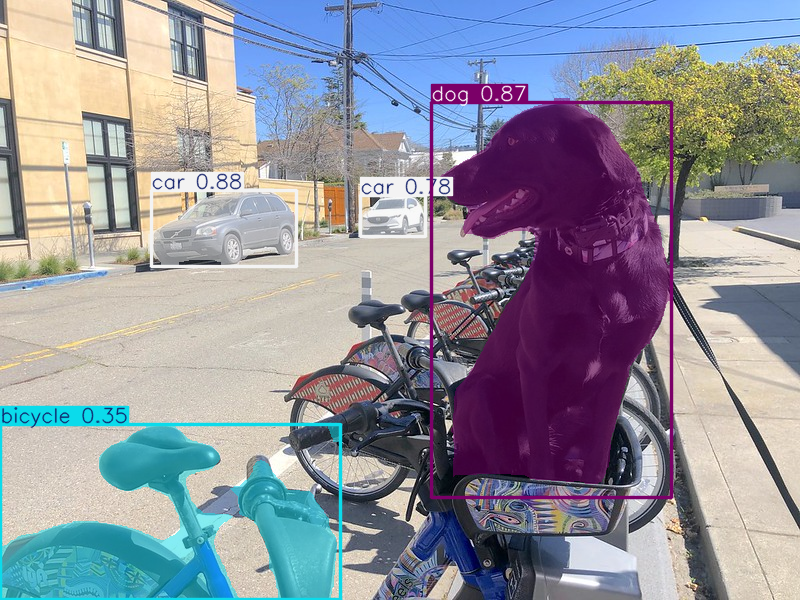

In [5]:
from PIL import Image
from ultralytics import YOLO

SEG_MODEL_NAME = "yolov8n-seg"

seg_model = YOLO(models_dir / f"{SEG_MODEL_NAME}.pt")
label_map = seg_model.model.names

res = seg_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

In [6]:
# instance segmentation model
seg_model_path = models_dir / f"{SEG_MODEL_NAME}_openvino_model/{SEG_MODEL_NAME}.xml"
if not seg_model_path.exists():
    seg_model.export(format="openvino", dynamic=True, half=True)

## 3. Device selection

Select the inference device (CPU, GPU, NPU, or AUTO) below:


In [48]:
device = device_widget()

device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU', 'NPU', 'AUTO'), value='AUTO')

### Compile OpenVINO FP32


In [69]:
import openvino as ov

core = ov.Core()
seg_ov_model = core.read_model(seg_model_path)

ov_config = {}
if device.value != "CPU":
    seg_ov_model.reshape({0: [1, 3, 640, 640]})
if "GPU" in device.value or ("AUTO" in device.value and "GPU" in core.available_devices):
    ov_config = {"GPU_DISABLE_WINOGRAD_CONVOLUTION": "YES"}
seg_compiled_model = core.compile_model(seg_ov_model, device.value, ov_config)

In [70]:
import torch


def infer(*args):
    result = seg_compiled_model(args)
    return torch.from_numpy(result[0]), torch.from_numpy(result[1])


seg_model.predictor.inference = infer
seg_model.predictor.model.pt = False

### Validation setup (for quantization calibration)


In [71]:
from zipfile import ZipFile

from ultralytics.data.utils import DATASETS_DIR


DATA_URL = "http://images.cocodataset.org/zips/val2017.zip"
LABELS_URL = "https://github.com/ultralytics/yolov5/releases/download/v1.0/coco2017labels-segments.zip"
CFG_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/v8.1.0/ultralytics/cfg/datasets/coco.yaml"

OUT_DIR = DATASETS_DIR

DATA_PATH = OUT_DIR / "val2017.zip"
LABELS_PATH = OUT_DIR / "coco2017labels-segments.zip"
CFG_PATH = OUT_DIR / "coco.yaml"


if not (OUT_DIR / "coco/labels").exists():
    download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
    download_file(LABELS_URL, LABELS_PATH.name, LABELS_PATH.parent)
    download_file(CFG_URL, CFG_PATH.name, CFG_PATH.parent)
    with ZipFile(LABELS_PATH, "r") as zip_ref:
        zip_ref.extractall(OUT_DIR)
    with ZipFile(DATA_PATH, "r") as zip_ref:
        zip_ref.extractall(OUT_DIR / "coco/images")

In [72]:
import numpy as np
from tqdm.notebook import tqdm
from ultralytics.utils.metrics import ConfusionMatrix


def test(
    model: ov.Model,
    core: ov.Core,
    data_loader: torch.utils.data.DataLoader,
    validator,
    num_samples: int = None,
):
    """
    OpenVINO YOLOv8 model accuracy validation function. Runs model validation on dataset and returns metrics
    Parameters:
        model (Model): OpenVINO model
        data_loader (torch.utils.data.DataLoader): dataset loader
        validator: instance of validator class
        num_samples (int, *optional*, None): validate model only on specified number samples, if provided
    Returns:
        stats: (Dict[str, float]) - dictionary with aggregated accuracy metrics statistics, key is metric name, value is metric value
    """
    validator.seen = 0
    validator.jdict = []
    validator.stats = dict(tp_m=[], tp=[], conf=[], pred_cls=[], target_cls=[], target_img=[])
    validator.batch_i = 1
    validator.confusion_matrix = ConfusionMatrix(names=validator.names)
    model.reshape({0: [1, 3, -1, -1]})
    num_outputs = len(model.outputs)
    compiled_model = core.compile_model(model)
    for batch_i, batch in enumerate(tqdm(data_loader, total=num_samples)):
        if num_samples is not None and batch_i == num_samples:
            break
        batch = validator.preprocess(batch)
        results = compiled_model(batch["img"])
        if num_outputs == 1:
            preds = torch.from_numpy(results[compiled_model.output(0)])
        else:
            preds = [
                torch.from_numpy(results[compiled_model.output(0)]),
                torch.from_numpy(results[compiled_model.output(1)]),
            ]
        preds = validator.postprocess(preds)
        validator.update_metrics(preds, batch)
    stats = validator.get_stats()
    return stats


def print_stats(stats: np.ndarray, total_images: int, total_objects: int):
    """
    Helper function for printing accuracy statistic
    Parameters:
        stats: (Dict[str, float]) - dictionary with aggregated accuracy metrics statistics, key is metric name, value is metric value
        total_images (int) -  number of evaluated images
        total objects (int)
    Returns:
        None
    """
    print("Boxes:")
    mp, mr, map50, mean_ap = (
        stats["metrics/precision(B)"],
        stats["metrics/recall(B)"],
        stats["metrics/mAP50(B)"],
        stats["metrics/mAP50-95(B)"],
    )
    # Print results
    print("    Best mean average:")
    s = ("%20s" + "%12s" * 6) % (
        "Class",
        "Images",
        "Labels",
        "Precision",
        "Recall",
        "mAP@.5",
        "mAP@.5:.95",
    )
    print(s)
    pf = "%20s" + "%12i" * 2 + "%12.3g" * 4  # print format
    print(pf % ("all", total_images, total_objects, mp, mr, map50, mean_ap))
    if "metrics/precision(M)" in stats:
        s_mp, s_mr, s_map50, s_mean_ap = (
            stats["metrics/precision(M)"],
            stats["metrics/recall(M)"],
            stats["metrics/mAP50(M)"],
            stats["metrics/mAP50-95(M)"],
        )
        # Print results
        print("    Macro average mean:")
        s = ("%20s" + "%12s" * 6) % (
            "Class",
            "Images",
            "Labels",
            "Precision",
            "Recall",
            "mAP@.5",
            "mAP@.5:.95",
        )
        print(s)
        pf = "%20s" + "%12i" * 2 + "%12.3g" * 4  # print format
        print(pf % ("all", total_images, total_objects, s_mp, s_mr, s_map50, s_mean_ap))

In [73]:
from ultralytics.utils import DEFAULT_CFG
from ultralytics.cfg import get_cfg
from ultralytics.data.converter import coco80_to_coco91_class
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import ops

args = get_cfg(cfg=DEFAULT_CFG)
args.data = str(CFG_PATH)

In [74]:
seg_validator = seg_model.task_map[seg_model.task]["validator"](args=args)
seg_validator.data = check_det_dataset(args.data)
seg_validator.stride = 32
seg_data_loader = seg_validator.get_dataloader(OUT_DIR / "coco/", 1)

seg_validator.is_coco = True
seg_validator.class_map = coco80_to_coco91_class()
seg_validator.names = seg_model.model.names
seg_validator.metrics.names = seg_validator.names
seg_validator.nc = seg_model.model.model[-1].nc
seg_validator.nm = 32
seg_validator.process = ops.process_mask
seg_validator.plot_masks = []

import torch

seg_validator.device = torch.device("cpu")
seg_validator.end2end = False

val: Fast image access  (ping: 0.00.1 ms, read: 1783.3801.0 MB/s, size: 170.8 KB)
val: Scanning C:\Users\anish\Cursor\Openvino\openvino_notebooks\notebooks\yolov8-optimization\datasets\coco\labels\val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 5.0Mit/s 0.0s


After definition test function and validator creation, we are ready for getting accuracy metrics
>**Note**: Model evaluation is time consuming process and can take several minutes, depending on the hardware. For reducing calculation time, we define `num_samples` parameter with evaluation subset size, but in this case, accuracy can be noncomparable with originally reported by the authors of the model, due to validation subset difference.
*To validate the models on the full dataset set `NUM_TEST_SAMPLES = None`.*

In [75]:
NUM_TEST_SAMPLES = 300

### Quantization (NNCF PTQ)


In [76]:
import ipywidgets as widgets

int8_model_seg_path = models_dir / f"{SEG_MODEL_NAME}_openvino_int8_model/{SEG_MODEL_NAME}.xml"

to_quantize = widgets.Checkbox(
    value=True,
    description="Quantization",
    disabled=False,
)

to_quantize

Checkbox(value=True, description='Quantization')

In [77]:
# Fetch skip_kernel_extension module
import requests

if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

The skip_kernel_extension extension is already loaded. To reload it, use:
  %reload_ext skip_kernel_extension


In [78]:
%%skip not $to_quantize.value

import nncf


def transform_fn(data_item:dict):
    """
    Quantization transform function. Extracts and preprocess input data from dataloader item for quantization.
    Parameters:
       data_item: Dict with data item produced by DataLoader during iteration
    Returns:
        input_tensor: Input data for quantization
    """
    input_tensor = seg_validator.preprocess(data_item)['img'].numpy()
    return input_tensor


quantization_dataset = nncf.Dataset(seg_data_loader, transform_fn)

In [79]:
%%skip not $to_quantize.value

if int8_model_seg_path.exists():
    quantized_seg_model = core.read_model(int8_model_seg_path)
    print(f"Loaded cached INT8 model from {int8_model_seg_path}")
else:
    quantized_seg_model = nncf.quantize(
        seg_ov_model,
        quantization_dataset,
        preset=nncf.QuantizationPreset.MIXED
    )
    ov.save_model(quantized_seg_model, str(int8_model_seg_path))
    print(f"Quantized and saved INT8 model to {int8_model_seg_path}")


Loaded cached INT8 model from models\yolov8n-seg_openvino_int8_model\yolov8n-seg.xml


### Compile OpenVINO INT8


In [80]:
%%skip not $to_quantize.value

ov_config = {}
if device.value != "CPU":
    quantized_seg_model.reshape({0: [1, 3, 640, 640]})
if "GPU" in device.value or ("AUTO" in device.value and "GPU" in core.available_devices):
    ov_config = {"GPU_DISABLE_WINOGRAD_CONVOLUTION": "YES"}

quantized_seg_compiled_model = core.compile_model(quantized_seg_model, device.value, ov_config)

In [81]:
%%skip not $to_quantize.value


def infer(*args):
    result = quantized_seg_compiled_model(args)
    return torch.from_numpy(result[0]), torch.from_numpy(result[1])

seg_model.predictor.inference = infer

### Benchmark: Inference Time & Throughput

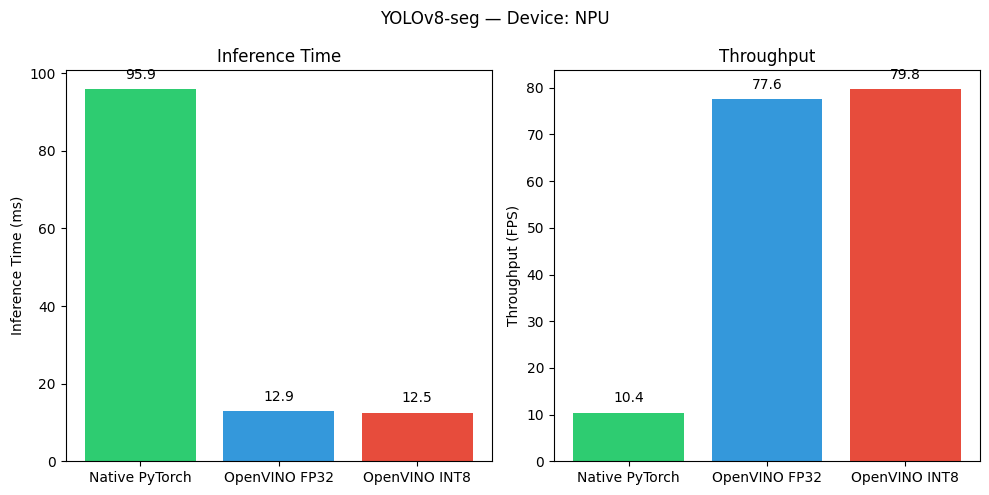

In [82]:

import time
import matplotlib.pyplot as plt

labels = ["Native PyTorch", "OpenVINO FP32", "OpenVINO INT8"]
colors = ["#2ecc71", "#3498db", "#e74c3c"]

dummy = np.random.randn(1, 3, 640, 640).astype(np.float32)
pt_src = str(IMAGE_PATH) if IMAGE_PATH.exists() else np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

# Benchmark inference (median of ~100 runs)
def benchmark_ov(compiled_model, n_warmup=5, n_iter=100):
    for _ in range(n_warmup):
        compiled_model([dummy])
    latencies = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        compiled_model([dummy])
        latencies.append((time.perf_counter() - t0) * 1000)
    return float(np.median(latencies))

def benchmark_pt(model, src, n_warmup=5, n_iter=100):
    for _ in range(n_warmup):
        model.predict(src, verbose=False)
    latencies = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        model.predict(src, verbose=False)
        latencies.append((time.perf_counter() - t0) * 1000)
    return float(np.median(latencies))

pt_model = YOLO(str(models_dir / f"{SEG_MODEL_NAME}.pt"))
pt_latency_ms = benchmark_pt(pt_model, pt_src)
ov_fp32_latency_ms = benchmark_ov(seg_compiled_model)
ov_int8_latency_ms = benchmark_ov(quantized_seg_compiled_model)
latencies = [pt_latency_ms, ov_fp32_latency_ms, ov_int8_latency_ms]
throughputs = [1000 / l for l in latencies]

# 2 charts: Inference Time and Throughput
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, vals, ylabel, title, fmt in [
    (axes[0], latencies, "Inference Time (ms)", "Inference Time", ".1f"),
    (axes[1], throughputs, "Throughput (FPS)", "Throughput", ".1f"),
]:
    bars = ax.bar(labels, vals, color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + (max(vals)*0.02 or 0.5), f"{b.get_height():{fmt}}", ha='center', va='bottom')
plt.suptitle(f"YOLOv8-seg — Device: {device.value}", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Side-by-side inference (PyTorch | FP32 | INT8)



image 1/1 C:\Users\anish\Cursor\Openvino\openvino_notebooks\notebooks\yolov8-optimization\data\coco_bike.jpg: 480x640 1 bicycle, 2 cars, 1 dog, 172.2ms
Speed: 2.9ms preprocess, 172.2ms inference, 6.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\anish\Cursor\Openvino\openvino_notebooks\notebooks\yolov8-optimization\data\coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 10.2ms
Speed: 4.7ms preprocess, 10.2ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\anish\Cursor\Openvino\openvino_notebooks\notebooks\yolov8-optimization\data\coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 17.1ms
Speed: 4.6ms preprocess, 17.1ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)


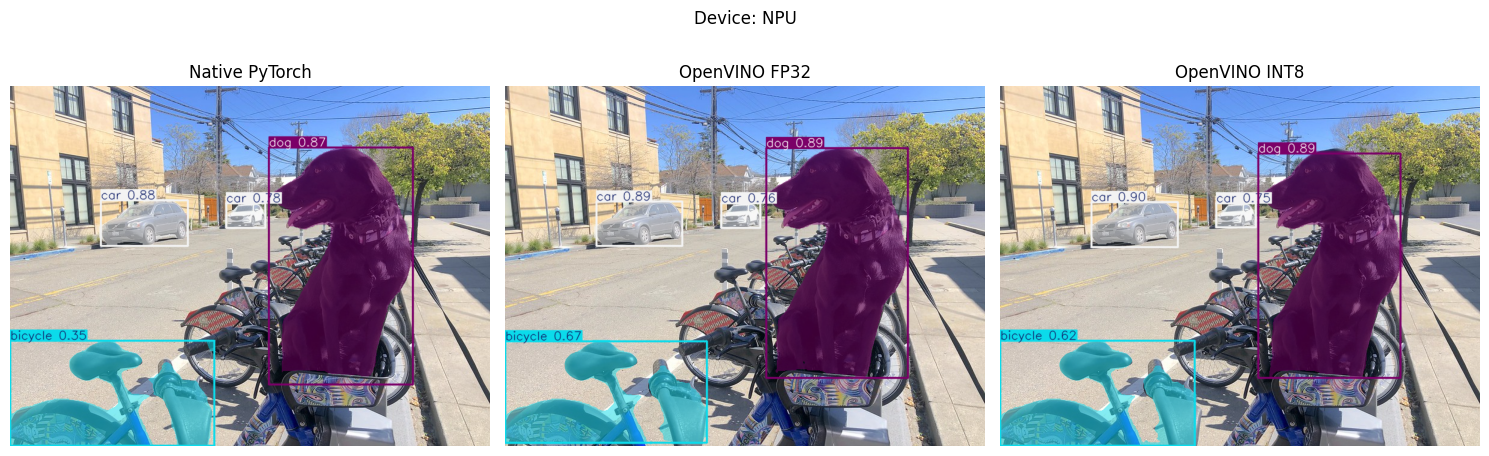

In [83]:
%%skip not $to_quantize.value

# Side-by-side inference: PyTorch | FP32 OpenVINO | INT8 OpenVINO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path = str(IMAGE_PATH)
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {img_path}")

# 1. PyTorch
pt_model = YOLO(str(models_dir / f"{SEG_MODEL_NAME}.pt"))
pt_res = pt_model(img_path)
pt_plot = pt_res[0].plot()[:, :, ::-1]  # BGR to RGB for display

# 2. FP32 OpenVINO
def infer_fp32(*args):
    r = seg_compiled_model(args)
    return torch.from_numpy(r[0]), torch.from_numpy(r[1])
seg_model.predictor.inference = infer_fp32
seg_model.predictor.model.pt = False
fp32_res = seg_model(img_path)
fp32_plot = fp32_res[0].plot()[:, :, ::-1]

# 3. INT8 OpenVINO
def infer_int8(*args):
    r = quantized_seg_compiled_model(args)
    return torch.from_numpy(r[0]), torch.from_numpy(r[1])
seg_model.predictor.inference = infer_int8
int8_res = seg_model(img_path)
int8_plot = int8_res[0].plot()[:, :, ::-1]

# Display side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pt_plot)
axes[0].set_title("Native PyTorch")
axes[0].axis("off")
axes[1].imshow(fp32_plot)
axes[1].set_title("OpenVINO FP32")
axes[1].axis("off")
axes[2].imshow(int8_plot)
axes[2].set_title("OpenVINO INT8")
axes[2].axis("off")
plt.suptitle(f"Device: {device.value}", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Live inference


In [84]:
import collections
import time
import numpy as np
import cv2
from IPython import display


In [85]:
def run_instance_segmentation_with_device(
    source=0,
    flip=False,
    use_popup=False,
    model=seg_ov_model,
    device_name=None,
):
    player = None
    device_str = device_name or device.value

    ov_config = {}
    if device_str != "CPU":
        model.reshape({0: [1, 3, 640, 640]})
    if "GPU" in device_str or ("AUTO" in device_str and "GPU" in core.available_devices):
        ov_config = {"GPU_DISABLE_WINOGRAD_CONVOLUTION": "YES"}
    compiled_model = core.compile_model(model, device_str, ov_config)

    def infer(*args):
        result = compiled_model(args)
        return torch.from_numpy(result[0]), torch.from_numpy(result[1])

    seg_model.predictor.inference = infer
    seg_model.predictor.model.pt = False

    try:
        player = VideoPlayer(source=source, flip=flip, fps=30)
        player.start()
        if use_popup:
            title = "Press ESC or Q to Exit"
            cv2.namedWindow(winname=title, flags=cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()
        while True:
            frame = player.next()
            if frame is None:
                print("Source ended")
                break
            scale = 1280 / max(frame.shape)
            if scale < 1:
                frame = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
            input_image = np.array(frame)
            start_time = time.time()
            detections = seg_model(input_image)
            stop_time = time.time()
            frame = detections[0].plot()

            processing_times.append(stop_time - start_time)
            if len(processing_times) > 200:
                processing_times.popleft()
            _, f_width = frame.shape[:2]
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            font_scale = f_width / 1000
            # FPS overlay (left)
            cv2.putText(frame, f"{processing_time:.1f}ms ({fps:.1f} FPS)", (20, 40),
                cv2.FONT_HERSHEY_COMPLEX, font_scale, (0, 0, 255), 1)
            # Device overlay (top-right, avoids overlap)
            device_text = f"Device: {device_str}"
            (dev_w, dev_h), _ = cv2.getTextSize(device_text, cv2.FONT_HERSHEY_COMPLEX, font_scale, 1)
            cv2.putText(frame, device_text, (f_width - dev_w - 20, 25 + dev_h),
                cv2.FONT_HERSHEY_COMPLEX, font_scale, (0, 0, 255), 1)
            if use_popup:
                cv2.imshow(title, frame)
                key = cv2.waitKey(1)
                if key in (27, ord('q'), ord('Q')):
                    # #region agent log
                    try:
                        import json, time as _t
                        _logp = __import__("pathlib").Path(r"c:\Users\anish\Cursor\Openvino\.cursor\debug.log")
                        _logp.parent.mkdir(parents=True, exist_ok=True)
                        with open(_logp, "a", encoding="utf-8") as _f:
                            _f.write(json.dumps({"location":"run_instance_seg","message":"exit_key","data":{"key":int(key) if key != -1 else -1},"timestamp":int(_t.time()*1000),"hypothesisId":"q_key"}) + "\n")
                    except Exception: pass
                    # #endregion
                    break
            else:
                _, enc = cv2.imencode(".jpg", frame)
                display.clear_output(wait=True)
                display.display(display.Image(data=enc))
    except (KeyboardInterrupt, RuntimeError) as e:
        print(e)
    finally:
        if player:
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()


In [86]:
WEBCAM_INFERENCE = True
if WEBCAM_INFERENCE:
    VIDEO_SOURCE = 0
else:
    VIDEO_URL = "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/people.mp4"
    VIDEO_SOURCE = "people.mp4"
    if not Path(VIDEO_SOURCE).exists():
        download_file(VIDEO_URL)


### Live FP32


In [87]:
run_instance_segmentation_with_device(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=True,
    model=seg_ov_model,
    device_name=str(device.value),
)



0: 640x640 2 persons, 13.5ms
Speed: 4.4ms preprocess, 13.5ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 11.7ms
Speed: 4.2ms preprocess, 11.7ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 10.8ms
Speed: 4.4ms preprocess, 10.8ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 11.9ms
Speed: 3.9ms preprocess, 11.9ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 11.3ms
Speed: 4.4ms preprocess, 11.3ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 11.6ms
Speed: 5.0ms preprocess, 11.6ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 12.1ms
Speed: 5.1ms preprocess, 12.1ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 11.6ms
Speed: 4.0ms preprocess, 11.6ms inference, 3.6ms postprocess per image at shape (1

### Live inference (INT8)


In [88]:
%%skip not $to_quantize.value

run_instance_segmentation_with_device(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=True,
    model=quantized_seg_model,
    device_name=str(device.value),
)



0: 640x640 1 person, 9.9ms
Speed: 3.2ms preprocess, 9.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 9.4ms
Speed: 2.5ms preprocess, 9.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 8.5ms
Speed: 2.7ms preprocess, 8.5ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 8.5ms
Speed: 2.6ms preprocess, 8.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 9.1ms
Speed: 2.6ms preprocess, 9.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 persons, 9.6ms
Speed: 3.1ms preprocess, 9.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 8.7ms
Speed: 2.9ms preprocess, 8.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 9.1ms
Speed: 3.0ms preprocess, 9.1ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 64